In [1]:
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons
from tqdm.auto import tqdm
from torch import Tensor, nn
import torchode as to
from torchtune.modules import RotaryPositionalEmbeddings

In [4]:
class Flow(nn.Module):
    def __init__(self, dim: int, h: int = 64):
        super().__init__()
        self.net = nn.GRU(
            dim + 1, h, num_layers=1, batch_first=True, bidirectional=True
        )
        self.proj = nn.Linear(h * 2, 1)

    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        t = t.unsqueeze(-1).expand_as(x_t)
        h_t = self.net(torch.stack([x_t, t], dim=-1))[0]  # (B, L, C)
        u_t = self.proj(h_t).squeeze(-1)
        return u_t

In [6]:
device = "cuda:1"
# Training
flow = Flow(dim=1, h=512).to(device)
flow.compile()

optimizer = torch.optim.AdamW(flow.parameters(), 1e-3)
loss_fn = nn.MSELoss()
B = 256
tau = torch.linspace(0, 1, 200, device=device)
for i in tqdm(range(1000)):
    freq = torch.rand(B, device=device) * torch.pi + torch.pi
    is_cos = torch.rand(B, device=device) > 0.5
    x_1 = torch.sin(tau[None, :] * freq[:, None] + is_cos[:, None] * torch.pi / 2)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(len(x_1), device=device)

    x_t = (1 - t.unsqueeze(-1)) * x_0 + t.unsqueeze(-1) * x_1
    dx_t = x_1 - x_0

    optimizer.zero_grad()
    loss = loss_fn(flow(t=t, x_t=x_t), dx_t)
    loss.backward()
    optimizer.step()
    if i % 10 == 0:
        print(loss)

  0%|          | 0/1000 [00:00<?, ?it/s]

tensor(1.5243, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(1.1184, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.8902, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.8065, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.5655, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.5090, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.4262, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.4162, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.4682, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.4133, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.3977, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.3571, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.3767, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.3441, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.3427, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.3327, device='cuda:1', grad_fn=<MseLossBackward0>)
tensor(0.2665, device='cuda:1', grad_fn=

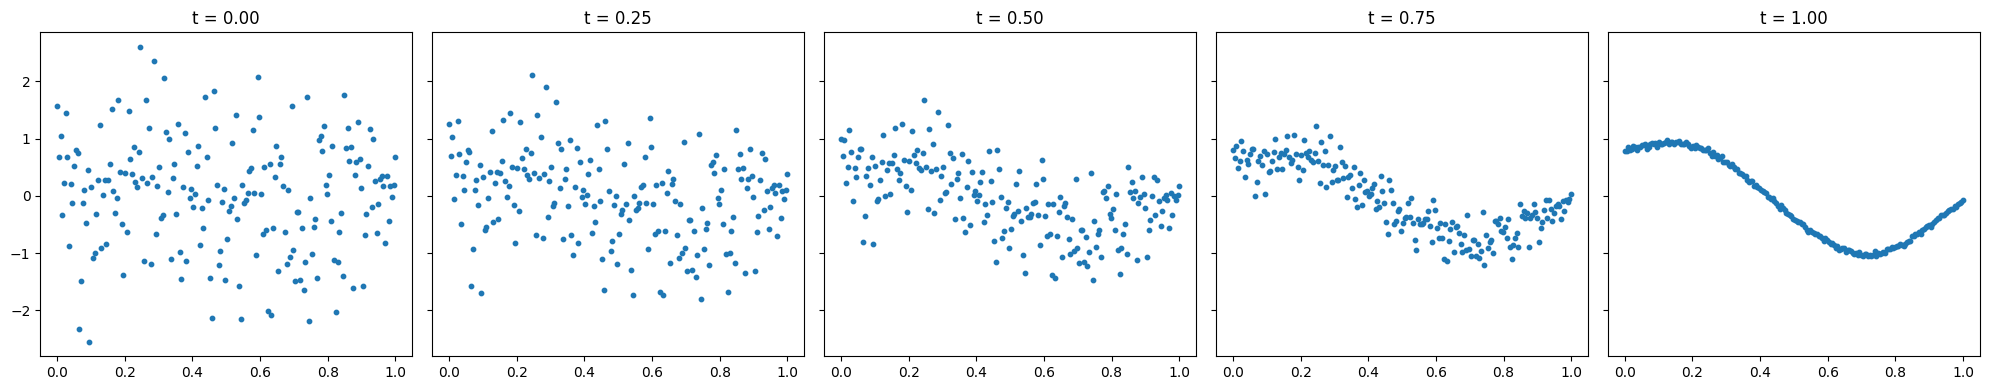

In [35]:
with torch.no_grad():
    # Sampling
    x = torch.randn(200, device=device)
    time_steps = torch.linspace(0, 1, 5, device=device)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)

    term = to.ODETerm(flow)
    step_method = to.Dopri5(term=term)
    step_size_controller = to.IntegralController(atol=1e-6, rtol=1e-3, term=term)
    solver = to.AutoDiffAdjoint(step_method, step_size_controller)
    jit_solver = torch.compile(solver)

    solution = jit_solver.solve(
        to.InitialValueProblem(
            y0=x.unsqueeze(0),
            t_eval=time_steps[None],
        )
    )
    for i, (ax, x) in enumerate(zip(axes, solution.ys[0])):
        ax.scatter(tau.cpu(), x.squeeze().cpu(), s=10)
        ax.set_title(f"t = {time_steps[i]:.2f}")

    plt.tight_layout()
    plt.show()
